# Informações do Trabalho

**Machine Learning & Artificial Intelligence for Data Science**

> Turma : 2TSCPV-2026

> Integrante: Alex Junior - RM562679

# Introdução:

Este trabalho tem como objetivo analisar e modelar o comportamento do Produto Interno Bruto (PIB) a partir de um dataset de série temporal mensal contendo variáveis de tráfego (como BRL, BRP, BRT, entre outras), além de variáveis defasadas (lags) e componentes sazonais. A análise foi estruturada em três etapas principais: 
- Avaliação da correlação entre o PIB e as variáveis explicativas, buscando identificar relações relevantes; 
- Experimentação de diferentes proporções de divisão entre treino e teste, com o objetivo de avaliar o impacto do tamanho da amostra na qualidade das previsões; 
- Teste de diferentes combinações de variáveis preditoras, visando identificar aquelas que resultam em menor erro de previsão. 

Dessa forma, o estudo integra análise exploratória e modelagem preditiva, utilizando métricas de erro para comparar o desempenho dos modelos.

Disponível em: [Fonte](https://github.com/diogenesjusto/FIAP/blob/master/Gradua%C3%A7%C3%A3o/2026/2TSCPV_20260317_p2.ipynb)

## Análise de Série Temporal
Nesse contexto, para uma série temporal dada, analise sazonalidades, avalie correlações e experimente modelos de previsão que minimizem o erro de previsão.

In [0]:
%pip install statsmodels

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [0]:
df_pib = pd.read_csv('https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv')
display(df_pib)
df_pib.describe()

Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,PRP,PRT,RJL,RJP,RJT,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,PIBi1,PIBi2,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,99.72,117.49,115.15,98.66,112.59,1,0,0,0,0,0,0,0,0,0,0,103.91,104.1,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.7,100.03,100.0
2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.6,99.24,97.55,102.4,90.2,100.51,0,1,0,0,0,0,0,0,0,0,0,103.09,103.91,104.1,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.7,100.03
3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,118.44,96.27,105.88,107.36,106.11,0,0,1,0,0,0,0,0,0,0,0,102.05,103.09,103.91,104.1,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.7
4,abr/04,106.77,95.36,118.34,100.49,94.58,123.55,101.02,91.79,117.25,100.96,105.64,99.25,104.65,0,0,0,1,0,0,0,0,0,0,0,110.43,102.05,103.09,103.91,104.1,106.27,104.52,102.59,102.24,99.96,101.93,101.17
5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,117.08,97.02,106.74,102.29,106.05,0,0,0,0,1,0,0,0,0,0,0,106.77,110.43,102.05,103.09,103.91,104.1,106.27,104.52,102.59,102.24,99.96,101.93
6,jun/04,109.19,89.25,119.93,96.11,87.79,128.51,96.83,84.0,112.53,94.28,103.06,100.74,102.7,0,0,0,0,0,1,0,0,0,0,0,108.08,106.77,110.43,102.05,103.09,103.91,104.1,106.27,104.52,102.59,102.24,99.96
7,jul/04,111.95,100.39,125.64,106.03,100.22,135.26,108.01,98.32,116.49,104.87,111.06,105.54,110.21,0,0,0,0,0,0,1,0,0,0,0,109.19,108.08,106.77,110.43,102.05,103.09,103.91,104.1,106.27,104.52,102.59,102.24
8,ago/04,110.92,94.2,129.67,102.13,93.66,139.38,103.81,87.53,124.59,100.88,106.74,107.29,106.82,0,0,0,0,0,0,0,1,0,0,0,111.95,109.19,108.08,106.77,110.43,102.05,103.09,103.91,104.1,106.27,104.52,102.59
9,set/04,110.18,95.54,126.7,102.5,94.93,138.84,104.68,91.66,111.49,98.8,106.18,105.65,106.09,0,0,0,0,0,0,0,0,1,0,0,110.92,111.95,109.19,108.08,106.77,110.43,102.05,103.09,103.91,104.1,106.27,104.52
10,out/04,109.71,99.46,124.85,105.14,98.58,136.18,106.93,93.66,107.63,98.69,111.41,105.84,110.55,0,0,0,0,0,0,0,0,0,1,0,110.18,110.92,111.95,109.19,108.08,106.77,110.43,102.05,103.09,103.91,104.1,106.27


,Unnamed: 0,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,PRP,PRT,RJL,RJP,RJT,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,PIBi1,PIBi2,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,69.500000,133.172681,125.440870,141.821159,129.053696,127.279493,157.326377,133.881594,130.086739,120.604855,126.678696,125.306377,121.557319,124.719058,0.086957,0.086957,0.086957,0.086957,0.086957,0.086957,0.079710,0.079710,0.079710,0.079710,0.079710,132.857754,132.532826,132.237464,131.895725,131.592609,131.250072,130.882391,130.523478,130.121449,129.742174,129.345652,128.951884
std,39.981246,15.752015,22.235065,18.220959,20.476254,23.683638,22.312447,22.493883,31.963978,16.857077,24.364310,15.095094,14.640984,14.820200,0.282798,0.282798,0.282798,0.282798,0.282798,0.282798,0.271831,0.271831,0.271831,0.271831,0.271831,15.899849,16.026464,16.132581,16.216998,16.371388,16.487866,16.616218,16.703195,16.737404,16.784401,16.835579,16.882134
min,1.000000,102.050000,89.250000,104.520000,96.110000,87.790000,109.830000,94.990000,82.380000,93.170000,89.640000,99.130000,90.200000,98.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,102.050000,102.050000,102.050000,102.050000,102.050000,102.050000,99.960000,99.960000,99.960000,99.960000,99.960000,99.960000
25%,35.250000,118.597500,105.477500,126.315000,109.932500,106.777500,138.945000,113.407500,103.327500,106.305000,105.580000,112.870000,108.820000,111.952500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,118.505000,118.485000,118.127500,117.710000,117.092500,116.515000,115.390000,114.992500,113.815000,113.430000,113.295000,113.062500
50%,69.500000,135.135000,122.255000,140.365000,127.205000,123.990000,155.850000,131.310000,128.950000,118.610000,123.835000,123.930000,121.645000,123.275000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.760000,134.360000,133.600000,133.170000,132.815000,132.400000,132.035000,131.270000,130.425000,129.695000,129.090000,128.670000
75%,103.750000,148.090000,143.272500,156.847500,145.585000,147.197500,176.302500,153.072500,149.277500,135.615000,145.395000,136.675000,134.805000,136.072500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,148.090000,147.937500,147.937500,147.627500,147.627500,147.217500,146.862500,146.175000,146.120000,145.680000,144.657500,144.242500
max,138.000000,156.980000,182.160000,179.710000,174.970000,183.720000,202.780000,179.560000,226.950000,154.690000,196.180000,162.640000,152.260000,158.810000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000,156.980000


In [0]:
def parse_ano_mes(col):
    meses = {
        'jan': '01', 'fev': '02', 'mar': '03', 'abr': '04',
        'mai': '05', 'jun': '06', 'jul': '07', 'ago': '08',
        'set': '09', 'out': '10', 'nov': '11', 'dez': '12'
    }

    df = col.str.split('/', expand=True)
    mes = df[0].map(meses)
    ano = '20' + df[1]

    return pd.to_datetime(ano + '-' + mes + '-01')

df_pib['date'] = parse_ano_mes(df_pib['ANO_MES'])
df_pib = df_pib.sort_values('date')
df_pib.set_index('date', inplace=True)

## Analisando o Dataset 

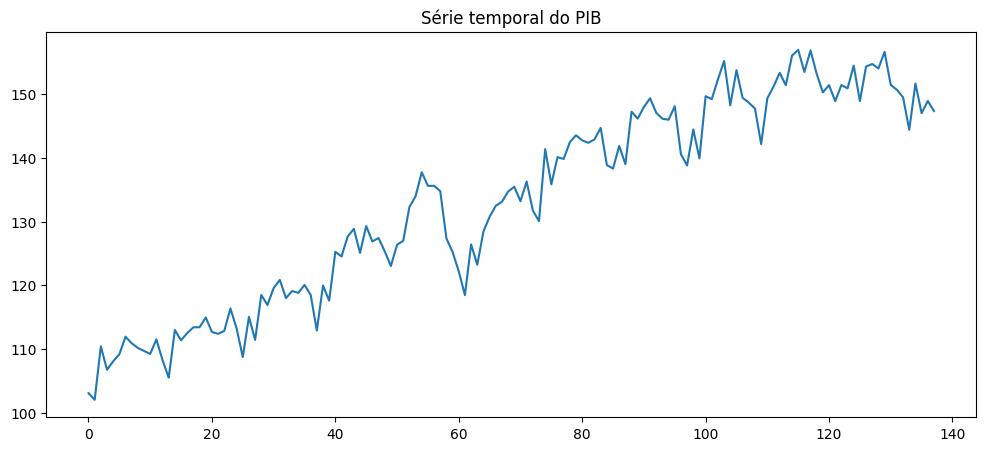

In [0]:
df_pib['PIB'].plot(figsize=(12,5), title='Série temporal do PIB')
plt.show()

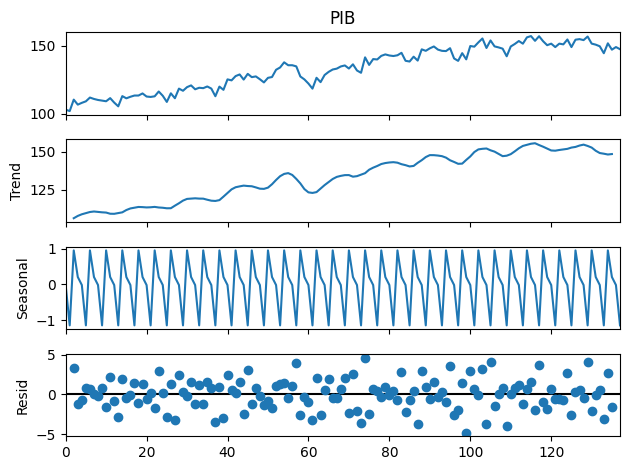

In [0]:
decomposicao = seasonal_decompose(df_pib['PIB'], model='additive', period=4)
decomposicao.plot()
plt.show()

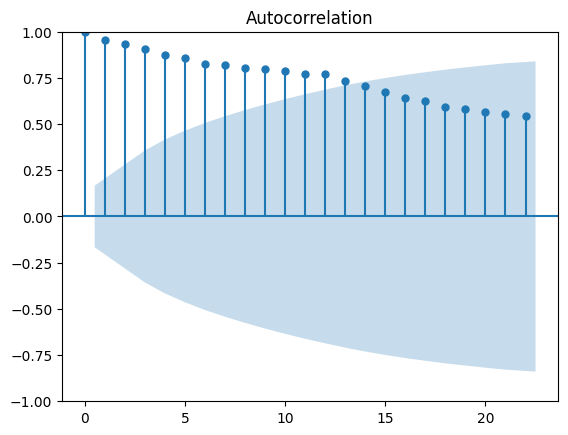

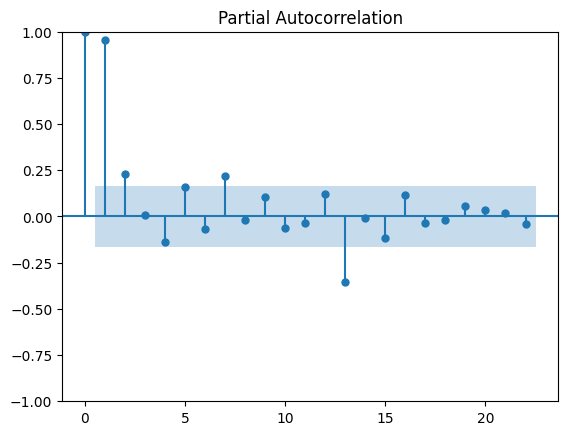

In [0]:
plot_acf(df_pib['PIB'])
plot_pacf(df_pib['PIB'])
plt.show()

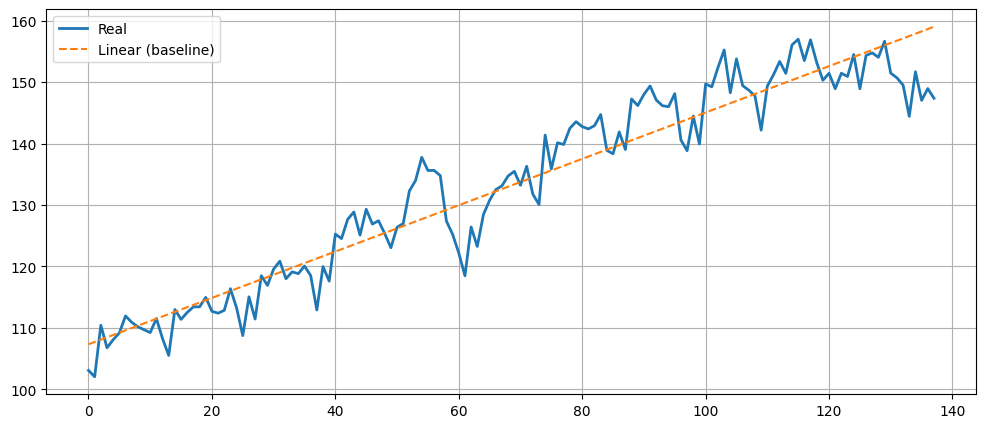

In [0]:
features = [
    'BRL','BRP','BRT','SLP','SPP','SPT',
    'PRL','PRP','PRT','RJL','RJP','RJT',
    'D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11',
    'PIBi1','PIBi2','PIBi3','PIBi4','PIBi5','PIBi6',
    'PIBi7','PIBi8','PIBi9','PIBi10','PIBi11','PIBi12'
]

X = df_pib[features]
y = df_pib['PIB']

model = LinearRegression()
model.fit(X, y)

df_pib['pred_ml'] = model.predict(X)

plt.figure(figsize=(12,5))

plt.plot(df_pib['PIB'], label='Real', linewidth=2)
plt.plot(df_pib['pred_linear'], '--', label='Linear (baseline)')

plt.legend()
plt.grid()
plt.show()

In [0]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, df_pib['pred_ml'])
print(mae)

0.9918722419095334


## Exercício 1: Análise de Correlação entre Variáveis
Nesse contexto, analise correlações entre as variáveis PIB x variáveis de tráfego (BRL, BRP, BRT, ...)

In [0]:
variaveis_trafego = [
    'BRL','BRP','BRT','SLP','SPP','SPT',
    'PRL','PRP','PRT','RJL','RJP','RJT'
]

correlacoes = df_pib[variaveis_trafego + ['PIB']].corr()

correlacoes_pib = correlacoes['PIB'].sort_values(ascending=False)

display(correlacoes_pib)

PIB    1.000000
SPT    0.951017
BRP    0.945026
RJP    0.942831
SPP    0.940794
BRT    0.923355
RJT    0.916856
SLP    0.912627
RJL    0.898519
BRL    0.875316
PRP    0.839292
PRT    0.825325
PRL    0.733248
Name: PIB, dtype: float64

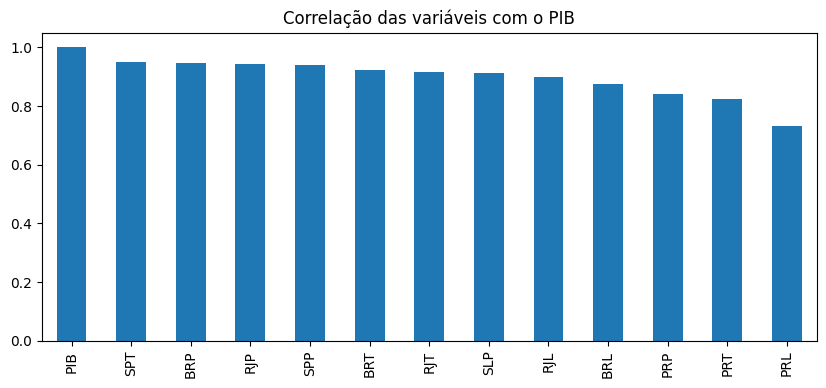

In [0]:
correlacoes_pib.plot(kind='bar', figsize=(10,4))
plt.title('Correlação das variáveis com o PIB')
plt.show()

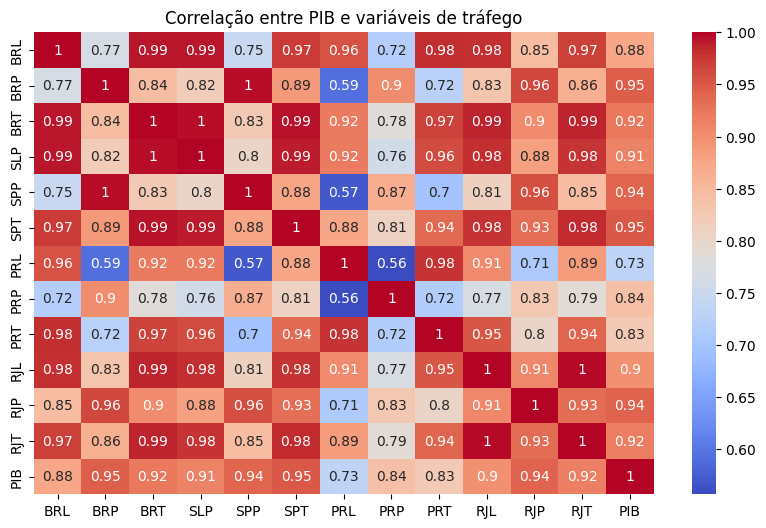

In [0]:
plt.figure(figsize=(10,6))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm')
plt.title('Correlação entre PIB e variáveis de tráfego')
plt.show()

## Considerações

Ao analisar a correlação entre o PIB e as variáveis de tráfego, percebi que algumas delas apresentam uma relação mais forte com o comportamento do PIB ao longo do tempo. Em especial, as variáveis que representam volumes totais, como SPT, BRP, e RJP, tendem a ter uma correlação positiva mais elevada. Isso faz sentido, já que um aumento na atividade econômica geralmente está associado a um maior fluxo de transporte e movimentação.

## Exercício 2: Experimentando tamanho
Experimente diferentes tamanhos de bases de treino e teste (qual tamanho mínimo da base de teste?)

In [0]:
def avaliar_split(df, features, proporcao_treino):
    
    train_size = int(len(df) * proporcao_treino)
    
    train = df.iloc[:train_size]
    test = df.iloc[train_size:]
    
    X_train = train[features]
    y_train = train['PIB']
    
    X_test = test[features]
    y_test = test['PIB']
    
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    
    return len(test), mae

In [0]:
proporcoes = [0.7, 0.8, 0.85, 0.9, 0.95]

for p in proporcoes:
    tamanho_teste, erro = avaliar_split(df_pib, features, p)
    print(f"Treino: {int(p*100)}% | Tamanho do Teste: {tamanho_teste} obs | MAE: {erro:.2f}")

Treino: 70% | Tamanho do Teste: 42 obs | MAE: 3.08
Treino: 80% | Tamanho do Teste: 28 obs | MAE: 3.00
Treino: 85% | Tamanho do Teste: 21 obs | MAE: 4.09
Treino: 90% | Tamanho do Teste: 14 obs | MAE: 2.27
Treino: 95% | Tamanho do Teste: 7 obs | MAE: 3.10


## Considerações

Para avaliar o impacto do tamanho das bases de treino e teste, foram realizados experimentos variando a proporção de dados utilizados para treinamento. é possível observar que, à medida que a base de treino aumenta, o modelo tende a apresentar melhor ajuste, porém a base de teste se torna menor, o que pode comprometer a confiabilidade da avaliação.

## Exercício 3: Experimentando variáveis
Experimente diferentes variáveis (além de BRP) para prever o PIB, e verifique (ao final) quais produzem um menor erro de previsão

In [0]:
def avaliar_modelo(df, features):
    
    train_size = int(len(df) * 0.8)
    
    train = df.iloc[:train_size]
    test = df.iloc[train_size:]
    
    X_train = train[features]
    y_train = train['PIB']
    
    X_test = test[features]
    y_test = test['PIB']
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    
    return mae

In [0]:
resultados = {}

resultados['BRP'] = avaliar_modelo(df_pib, ['BRP'])

variaveis = ['BRL','BRT','SLP','SPP','SPT','PRL','PRP','PRT','RJL','RJP','RJT']

for var in variaveis:
    resultados[var] = avaliar_modelo(df_pib, [var])

resultados['BRP + BRT'] = avaliar_modelo(df_pib, ['BRP','BRT'])

todas = variaveis + ['BRP']
resultados['Todas'] = avaliar_modelo(df_pib, todas)

print(resultados)

{'BRP': 5.114846445101517, 'BRL': 5.820465478719073, 'BRT': 4.191696626979493, 'SLP': 5.299224697249277, 'SPP': 6.498112188724559, 'SPT': 3.6558658637317185, 'PRL': 12.438876433317034, 'PRP': 3.8602114522720816, 'PRT': 8.360773839387639, 'RJL': 4.455363064767748, 'RJP': 5.1835120140160456, 'RJT': 4.327632430406481, 'BRP + BRT': 2.5485111841063874, 'Todas': 2.7289228489105457}


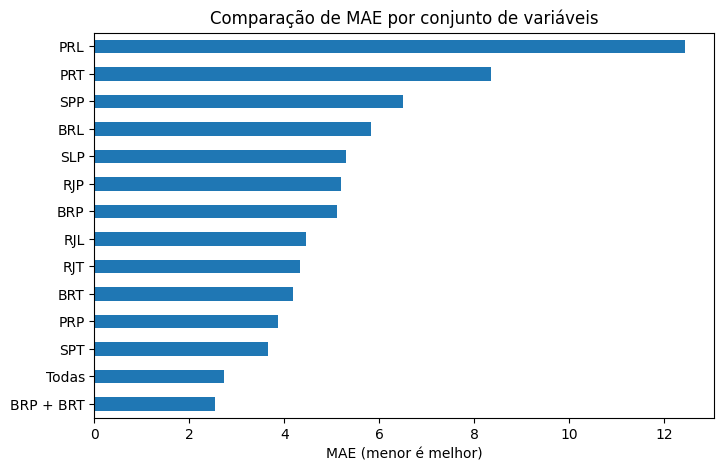

In [0]:
df_resultados = pd.Series(resultados).sort_values()

df_resultados.plot(kind='barh', figsize=(8,5))
plt.title('Comparação de MAE por conjunto de variáveis')
plt.xlabel('MAE (menor é melhor)')
plt.show()

## Considerações
Para este exercício, foram testadas diferentes variáveis como preditoras do PIB, avaliando o desempenho dos modelos por meio do erro médio absoluto (MAE).

Inicialmente, foi utilizado o BRP como variável base. Em seguida, foram testadas outras variáveis individualmente, bem como combinações entre elas. Observou-se que algumas variáveis, como SPT, PRP e BRT, apresentaram melhor desempenho individual, indicando maior relação com o PIB.

O melhor resultado foi obtido com a combinação de BRP e BRT, que apresentou o menor erro de previsão. Isso indica que essas variáveis, quando utilizadas em conjunto, conseguem capturar melhor o comportamento do PIB do que quando utilizadas isoladamente.

Além disso, ao utilizar todas as variáveis disponíveis, o modelo também apresentou bom desempenho, porém não superou a combinação mais simples. Isso sugere que a inclusão de muitas variáveis pode introduzir redundância ou ruído, prejudicando a capacidade de generalização do modelo.

Dessa forma, conclui-se que a escolha e combinação adequada de variáveis é fundamental para a qualidade do modelo, sendo que abordagens mais enxutas e bem selecionadas podem ser mais eficazes do que o uso de todas as variáveis disponíveis.
